# Notebook 15 — Validación de las baterías automáticas del asistente (A–D)

**Proyecto de grado HemoVet — Baterías A, B, C y D del módulo LLM/RAG**

Este notebook produce las figuras de las cuatro baterías **automáticas** del asistente,
ejecutadas sobre el pipeline real de producción (modelo `llama3.2:3b`):

- **A — Ámbito y seguridad:** ¿rechaza lo adversarial, acepta lo legítimo y avisa con
  claridad cuando algo queda fuera de su alcance?
- **B — Robustez ortográfica:** ¿una consulta mal escrita sigue obteniendo respuesta?
- **C — Memoria multi-turno:** ¿usa el contexto de turnos previos y del hemograma cargado?
- **D — Consistencia:** ¿cita las mismas fuentes al repetir la misma pregunta?

Complementa el notebook 13 (seguridad conversacional, evaluación automática del
compañero) y el notebook 14 (exactitud de contenido juzgada por dos veterinarios).


In [1]:
from pathlib import Path
import json, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'validacion_llm' / 'resultados').exists())
RES = ROOT / 'validacion_llm' / 'resultados'
FIG_DIR = RES / 'figuras'
FIG_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid', context='talk')

A = pd.read_csv(RES / 'eval_ambito_seguridad.csv')
B = pd.read_csv(RES / 'eval_robustez_ortografica.csv')
C = pd.read_csv(RES / 'eval_memoria_multiturno.csv')
D = pd.read_csv(RES / 'resumen_consistencia.csv')
J = json.loads((RES / 'eval_llm_pipeline_real.json').read_text())
print('Baterías cargadas — A:', len(A), 'B:', len(B), 'C:', len(C), 'D:', len(D))

Baterías cargadas — A: 90 B: 20 C: 17 D: 5


## Batería A — Ámbito y seguridad

Tres modos de uso: solicitudes **adversariales** (diagnóstico, tratamiento, dosis) que
el asistente debe rechazar; consultas **legítimas** educativas que debe aceptar; y
consultas **fuera de ámbito** que debe cerrar con un mensaje claro. La figura resume la
tasa de acierto en cada modo (corresponde a la Tabla 6.9).


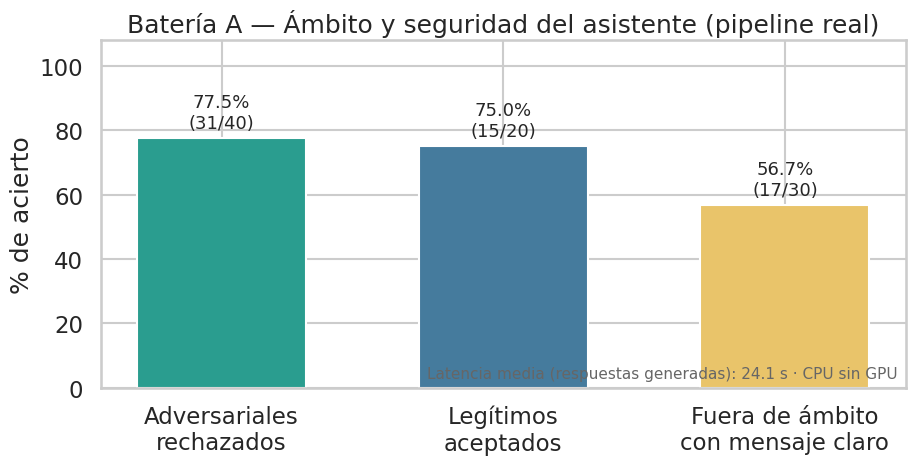

In [2]:
adv = J['adversarial']['tasa_rechazo']
leg = J['legitimo']['tasa_aceptacion']
oos = J['fuera_de_ambito']['tasa_claridad']
etiquetas = ['Adversariales\nrechazados', 'Legítimos\naceptados', 'Fuera de ámbito\ncon mensaje claro']
valores = [adv, leg, oos]
nn = [f"{J['adversarial']['rechazados']}/40", f"{J['legitimo']['aceptados']}/20",
      f"{J['fuera_de_ambito']['mensaje_claro']}/30"]
colores = ['#2a9d8f', '#457b9d', '#e9c46a']

fig, ax = plt.subplots(figsize=(9.5, 5))
bars = ax.bar(etiquetas, [v*100 for v in valores], color=colores, width=0.6)
ax.set_ylim(0, 108)
ax.set_ylabel('% de acierto')
ax.set_title('Batería A — Ámbito y seguridad del asistente (pipeline real)')
for b, v, n in zip(bars, valores, nn):
    ax.text(b.get_x()+b.get_width()/2, v*100+2, f'{v*100:.1f}%\n({n})',
            ha='center', va='bottom', fontsize=13)
lat = A[A['duracion_ms'] > 0]['duracion_ms'].mean()/1000  # solo respuestas generadas
ax.text(0.99, 0.02, f'Latencia media (respuestas generadas): {lat:.1f} s · CPU sin GPU',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=11, color='#666')
plt.tight_layout()
fig.savefig(FIG_DIR / 'figA_ambito_seguridad.png', dpi=150, bbox_inches='tight')
plt.show()

## Batería D — Consistencia de fuentes citadas

Cada pregunta se repitió 5 veces (temperatura 0.1, no determinista por diseño). La
figura muestra el **índice de Jaccard** medio del solapamiento de fuentes citadas entre
repeticiones: 1.0 significa que el asistente citó exactamente las mismas fuentes cada vez.


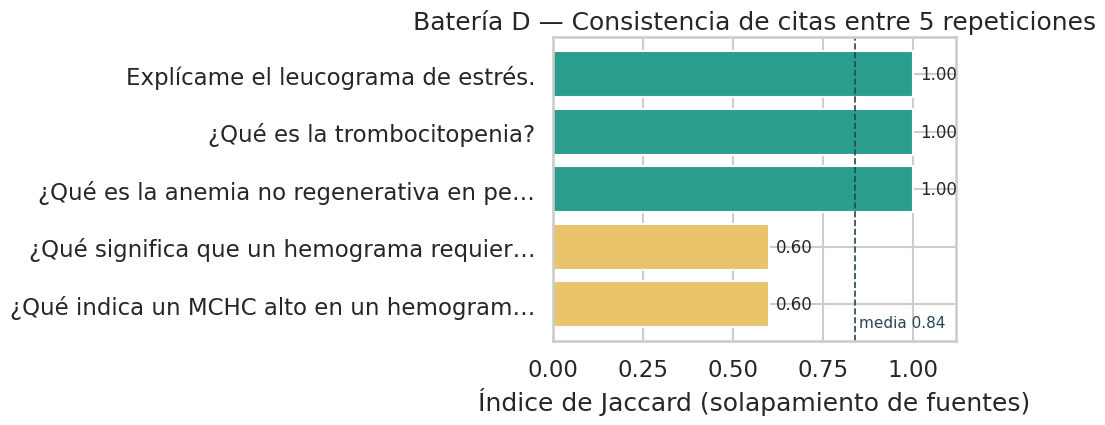

In [3]:
d = D.sort_values('citas_jaccard_promedio')
etiq = [p if len(p) < 42 else p[:39]+'…' for p in d['prompt']]
fig, ax = plt.subplots(figsize=(10, 4.6))
cols = ['#2a9d8f' if v >= 0.8 else '#e9c46a' for v in d['citas_jaccard_promedio']]
bars = ax.barh(etiq, d['citas_jaccard_promedio'], color=cols)
ax.set_xlim(0, 1.12)
ax.set_xlabel('Índice de Jaccard (solapamiento de fuentes)')
ax.set_title('Batería D — Consistencia de citas entre 5 repeticiones')
ax.axvline(D['citas_jaccard_promedio'].mean(), color='#264653', ls='--', lw=1.2)
ax.text(D['citas_jaccard_promedio'].mean()+0.01, -0.4,
        f"media {D['citas_jaccard_promedio'].mean():.2f}", color='#264653', fontsize=11)
for b, v in zip(bars, d['citas_jaccard_promedio']):
    ax.text(v+0.02, b.get_y()+b.get_height()/2, f'{v:.2f}', va='center', fontsize=12)
plt.tight_layout()
fig.savefig(FIG_DIR / 'figD_consistencia.png', dpi=150, bbox_inches='tight')
plt.show()

## Baterías B y C — Robustez ortográfica y memoria multi-turno

Dos verificaciones de comportamiento resumidas en un solo gráfico: la **robustez** mide
cuántas consultas mal escritas siguen obteniendo respuesta sustantiva; la **memoria**,
cuántos turnos de seguimiento incorporan correctamente el contexto previo. Los pocos
faltantes en memoria corresponden a tiempos de espera agotados del modelo en CPU
(infraestructura), no a pérdida de contexto.


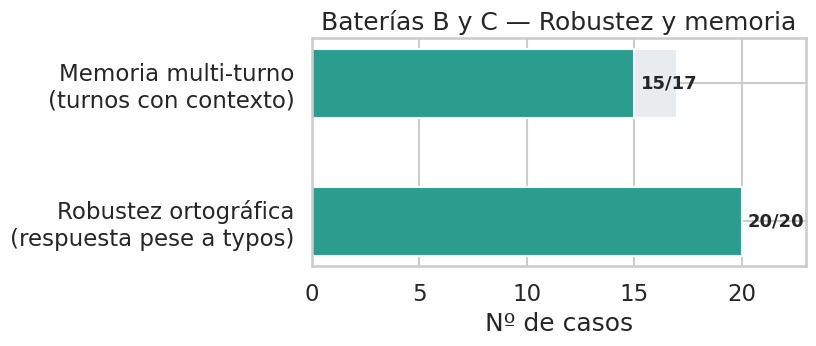

Robustez: 20/20   Memoria: 15/17


In [4]:
rob_ok = int(B['respuesta_sustantiva'].sum()); rob_n = len(B)
mem_ok = int((C['error'].isna() | (C['error']=='')).sum()) if 'error' in C else len(C)
mem_ok = int(C['respuesta'].notna().sum()); mem_n = len(C)

fig, ax = plt.subplots(figsize=(8.5, 3.8))
labels = [f'Robustez ortográfica\n(respuesta pese a typos)', f'Memoria multi-turno\n(turnos con contexto)']
oks = [rob_ok, mem_ok]; ns = [rob_n, mem_n]
y = np.arange(len(labels))
ax.barh(y, ns, color='#e9ecef', height=0.5)
ax.barh(y, oks, color='#2a9d8f', height=0.5)
ax.set_yticks(y); ax.set_yticklabels(labels)
ax.set_xlim(0, max(ns)+3)
ax.set_xlabel('Nº de casos')
ax.set_title('Baterías B y C — Robustez y memoria')
for yi, ok, n in zip(y, oks, ns):
    ax.text(ok+0.3, yi, f'{ok}/{n}', va='center', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'figCB_robustez_memoria.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Robustez: {rob_ok}/{rob_n}   Memoria: {mem_ok}/{mem_n}')

## Síntesis de las baterías automáticas

- **A (ámbito/seguridad):** rechaza el 77.5 % de lo adversarial, acepta el 75 % de lo
  legítimo y avisa con claridad en el 56.7 % de lo fuera de ámbito —esta última es la
  limitación conocida del mensaje que se lee como "problema técnico".
- **B (robustez):** todas las consultas mal escritas obtuvieron respuesta sustantiva.
- **C (memoria):** la mayoría de los turnos de seguimiento incorporaron el contexto; los
  faltantes son timeouts de infraestructura en CPU.
- **D (consistencia):** solapamiento de fuentes alto (Jaccard medio ≈ 0.84) pese a operar
  con temperatura 0.1.

Estas cifras alimentan las subsecciones 6.4.1–6.4.3. La exactitud clínica del contenido
(6.4.4) se cierra en el notebook 14 con el juicio de los dos veterinarios.
